In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats

In [2]:
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")

df = pd.read_csv(BASE_FILE)

print(df.shape)
df.head()

(239, 60)


,unique_patient_id,ethnicity,nht_auth_date,nht_start_date,bmi,specific_nht_used,age,adt_start_date,adt_agent,hx_smoking,...,bp_meds_post_binary,lipid_meds_post_binary,dm_meds_post_binary,at_risk,lifestyle_counseling,dm_severity,ethnicity_enc,specific_nht_used_enc,adt_agent_enc,prescribing_provider_enc
0,1.0,NaN,2022-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,27.0
1,2.0,NaN,2022-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,27.0
2,3.0,Caucasian,2022-01-12,2022-02-01,25.99,Darolutamide,73.0,2018-01-26,Lupron,1.0,...,0.0,0.0,0.0,0.0,0,0.0,2.0,2.0,2.0,27.0
3,4.0,Asian,2022-01-14,2022-02-14,22.55,Apalutamide,93.0,2021-12-01,Bicalutamide,0.0,...,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,42.0
4,5.0,NaN,2022-01-19,NaN,NaN,Abiraterone,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,7.0


In [17]:
# document missingness
na_count = df["hx_htn"].isna().sum()
na_pct = na_count / len(df) * 100

print(f"Missing hx_htn: {na_count} ({na_pct:.1f}%) out of {len(df)} patients")

Missing hx_htn: 39 (16.3%) out of 239 patients


In [11]:
# prevalence

valid_htn = df["hx_htn"].notna()

n_total = valid_htn.sum()
n_htn = df.loc[valid_htn, "hx_htn"].sum()
pct_htn = n_htn / n_total * 100

print(f"Overall hx_htn prevalence: {n_htn}/{n_total} ({pct_htn:.1f}%) [excluding missing]")

Overall hx_htn prevalence: 118.0/200 (59.0%) [excluding missing]


In [50]:
# treatment patterns
htn_df = df[df["hx_htn"] == 1]

# counts and percentages
nht_counts = htn_df["specific_nht_used"].value_counts()
nht_pct = htn_df["specific_nht_used"].value_counts(normalize=True) * 100

# risk rate (mean of binary outcome = proportion at_risk = 1)
risk_rate = htn_df.groupby("specific_nht_used")["at_risk"].mean() * 100

# combine into one table
treatment_table = pd.DataFrame({
    "count": nht_counts,
    "percent": nht_pct.round(1),
    "risk_rate (%)": risk_rate.round(1)
})

# sort (optional, keeps consistent order)
treatment_table = treatment_table.sort_values(by="count", ascending=False)

print("\nNHT agent distribution among hypertensive patients:")
print(treatment_table)


NHT agent distribution among hypertensive patients:
                   count  percent  risk_rate (%)
specific_nht_used                               
Abiraterone           55     46.6           52.7
Darolutamide          46     39.0           39.1
Enzalutamide           9      7.6           33.3
Apalutamide            8      6.8           37.5


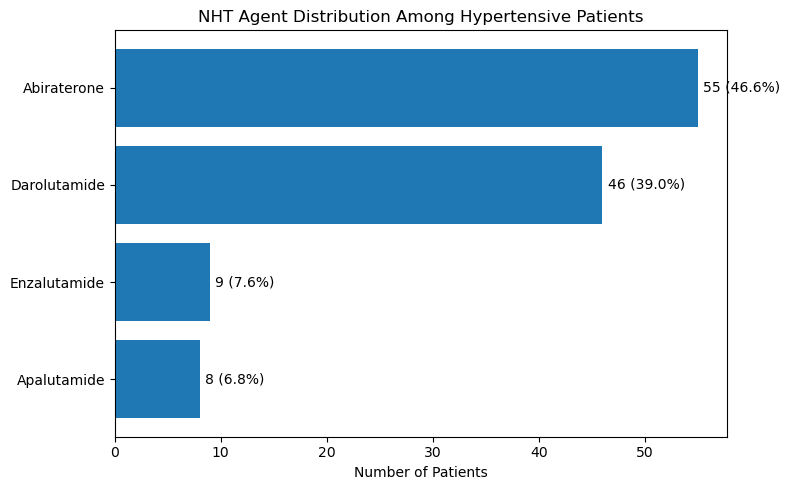

In [ ]:
# plot treatment patterns
htn_df = df[df["hx_htn"] == 1]

agent_counts = htn_df["specific_nht_used"].value_counts()
agent_pct = htn_df["specific_nht_used"].value_counts(normalize=True) * 100

agent_counts = agent_counts.sort_values(ascending=False)
agent_pct = agent_pct[agent_counts.index]

plt.figure(figsize=(8, 5))

bars = plt.barh(agent_counts.index, agent_counts.values)

plt.gca().invert_yaxis()

for i, agent in enumerate(agent_counts.index):
    count = agent_counts[agent]
    pct = agent_pct[agent]
    plt.text(count + 0.5, i, f"{count} ({pct:.1f}%)", va="center")

plt.xlabel("Number of Patients")
plt.title("NHT Agent Distribution Among Hypertensive Patients")

plt.tight_layout()
plt.show()

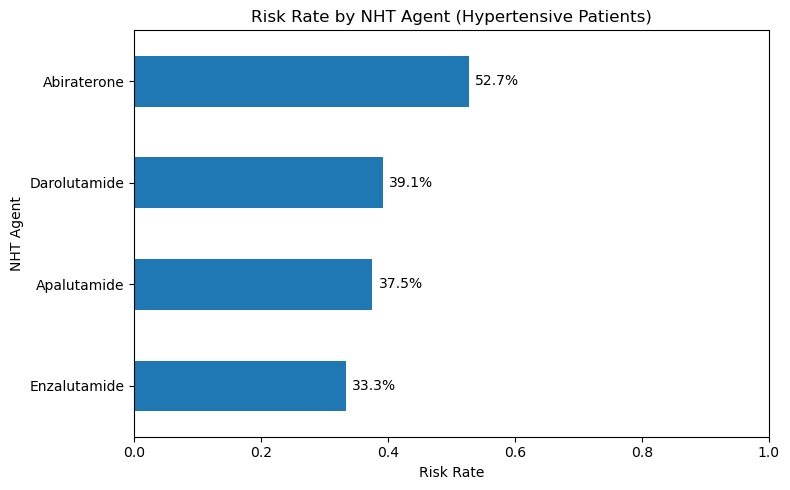

In [55]:
import matplotlib.pyplot as plt

# subset to hypertensive patients
htn_df = df[df["hx_htn"] == 1]

# compute risk rates
risk_by_nht = (
    htn_df.groupby("specific_nht_used")["at_risk"]
    .mean()
    .sort_values(ascending=True)  # ascending works better for horizontal bars
)

# plot (horizontal)
ax = risk_by_nht.plot(kind="barh", figsize=(8,5))

ax.set_title("Risk Rate by NHT Agent (Hypertensive Patients)")
ax.set_ylabel("NHT Agent")
ax.set_xlabel("Risk Rate")

# set x-axis from 0 to 1 (since it's a proportion)
ax.set_xlim(0, 1)

# annotate bars
for i, v in enumerate(risk_by_nht):
    ax.text(v + 0.01, i, f"{v*100:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [ ]:
# table: risk rates by hx_htn

counts = pd.crosstab(df["hx_htn"], df["at_risk"]).reindex([0, 1])

percents = counts.div(counts.sum(axis=1), axis=0) * 100

table = counts.astype(str) + " (" + percents.round(1).astype(str) + "%)"

table.index = ["hx_htn = 0", "hx_htn = 1"]

table

at_risk,0.0,1.0
hx_htn = 0,57 (69.5%),25 (30.5%)
hx_htn = 1,65 (55.1%),53 (44.9%)


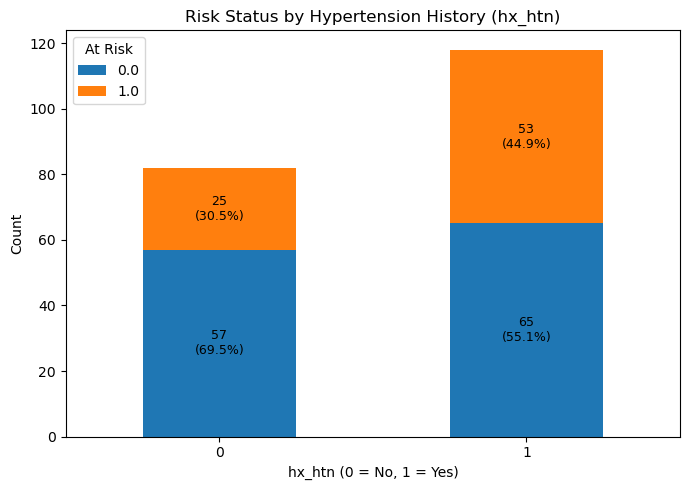

In [ ]:
# plot: risk rates by hx_htn

ct = pd.crosstab(df["hx_htn"], df["at_risk"]).reindex([0, 1])

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct.plot(kind="bar", stacked=True, figsize=(7,5))

ax.set_title("Risk Status by Hypertension History (hx_htn)")
ax.set_xlabel("hx_htn (0 = No, 1 = Yes)")
ax.set_ylabel("Count")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.legend(title="At Risk")

for i, idx in enumerate(ct.index):
    bottom = 0
    for j, col in enumerate(ct.columns):
        value = ct.loc[idx, col]
        pct = ct_pct.loc[idx, col]

        if value > 0:
            ax.text(
                i,
                bottom + value / 2,
                f"{value}\n({pct:.1f}%)",
                ha="center",
                va="center",
                fontsize=9
            )
        bottom += value

plt.tight_layout()
plt.show()

In [ ]:
# Chi Square test - hx_htn and at_risk

table = pd.crosstab(df["hx_htn"], df["at_risk"])
table

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

expected_df = pd.DataFrame(expected, 
                            index=table.index, 
                            columns=table.columns)

expected_df


Chi-square statistic: 3.648292964430915
p-value: 0.05612670974056949
Degrees of freedom: 1


at_risk,0.0,1.0
hx_htn,,
0.0,50.02,31.98
1.0,71.98,46.02


In [ ]:
# Fisher's exact test hx_htn and at_risk

from scipy.stats import fisher_exact

oddsratio, p_fisher = fisher_exact(table)

print("Odds ratio:", oddsratio)
print("Fisher p-value:", p_fisher)

Odds ratio: 1.859076923076923
Fisher p-value: 0.055008905758340595


In [49]:
# Chi Square test by NHT within hypertensive patients

htn_df = df[df["hx_htn"] == 1]
table_htn = pd.crosstab(htn_df["specific_nht_used"], htn_df["at_risk"])
print(table_htn)

chi2, p, dof, expected = chi2_contingency(table_htn)
print("----")
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

at_risk            0.0  1.0
specific_nht_used          
Abiraterone         26   29
Apalutamide          5    3
Darolutamide        28   18
Enzalutamide         6    3
----
Chi-square statistic: 2.6445600830670575
p-value: 0.4497310865905908
degrees of freedom: 3


In [77]:
import statsmodels.formula.api as smf

model = smf.logit(
    "at_risk ~ hx_htn * C(specific_nht_used)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.650321
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                at_risk   No. Observations:                  200
Model:                          Logit   Df Residuals:                      192
Method:                           MLE   Df Model:                            7
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                 0.02755
Time:                        18:57:41   Log-Likelihood:                -130.06
converged:                       True   LL-Null:                       -133.75
Covariance Type:            nonrobust   LLR p-value:                    0.3913
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                 

In [88]:
# Was treatment choice (NHT agent) influenced by hypertension status?
# / Is specific_nht_used associated with hx_htn?

table = pd.crosstab(df["hx_htn"], df["specific_nht_used"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("dof:", dof)

print("\nExpected counts:")
print(pd.DataFrame(expected, index=table.index, columns=table.columns))

Chi-square: 1.6173411236617
p-value: 0.6554642596409901
dof: 3

Expected counts:
specific_nht_used  Abiraterone  Apalutamide  Darolutamide  Enzalutamide
hx_htn                                                                 
0.0                      36.08         5.33          32.8          7.79
1.0                      51.92         7.67          47.2         11.21


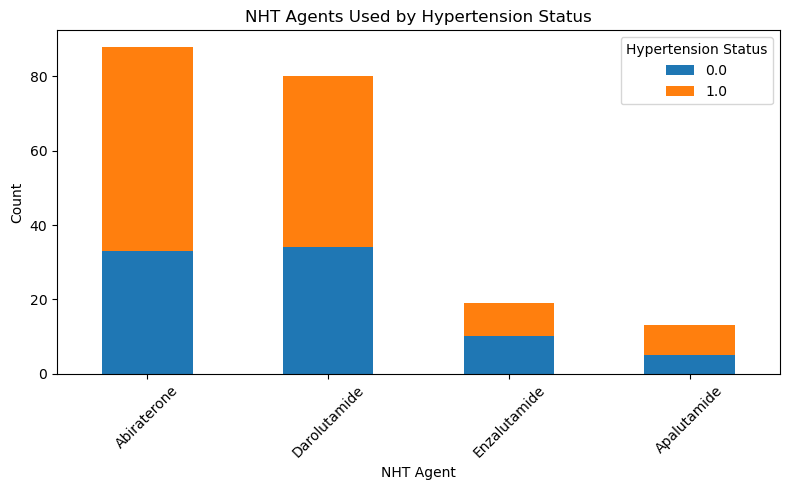

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["hx_htn"])

# reorder rows by TOTAL bar size (descending)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# plot stacked bar chart (counts)
ax = ct.plot(kind="bar", stacked=True, figsize=(8,5))

# labels
ax.set_title("NHT Agents Used by Hypertension Status")
ax.set_xlabel("NHT Agent")
ax.set_ylabel("Count")

plt.legend(title="Hypertension Status")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

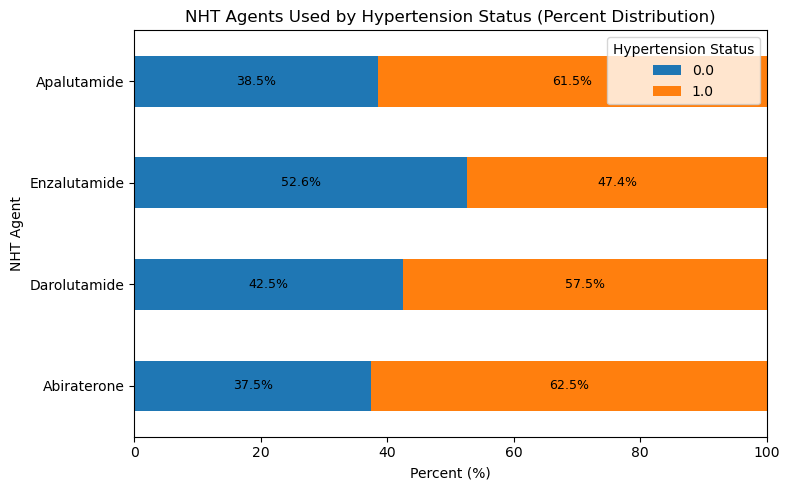

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# contingency table (counts)
ct = pd.crosstab(df["specific_nht_used"], df["hx_htn"])

# reorder by total bar size (descending)
ct["Total"] = ct.sum(axis=1)
ct = ct.sort_values("Total", ascending=False).drop(columns="Total")

# convert to row-wise percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# plot horizontal stacked percentage bar chart
ax = ct_pct.plot(kind="barh", stacked=True, figsize=(8,5))

# labels
ax.set_title("NHT Agents Used by Hypertension Status (Percent Distribution)")
ax.set_xlabel("Percent (%)")
ax.set_ylabel("NHT Agent")

plt.legend(title="Hypertension Status")

# annotate percentages
for i, idx in enumerate(ct_pct.index):
    left = 0
    for col in ct_pct.columns:
        val = ct_pct.loc[idx, col]
        ax.text(left + val/2, i, f"{val:.1f}%", va="center", ha="center", fontsize=9)
        left += val

plt.xlim(0, 100)
plt.tight_layout()
plt.show()